# Лабораторная работа №1
## Предобработка текстовых данных для анализа судебных документов

In [2]:
# Установка зависимостей (выполните один раз)
!pip install pymorphy2 natasha nltk matplotlib wordcloud --quiet
!pip install pymorphy2-dicts-ru --quiet

### ЗАДАЧА 1. ФОРМИРОВАНИЕ УЧЕБНОГО КОРПУСА СУДЕБНЫХ ДОКУМЕНТОВ

In [3]:
import re
import string
import json
from collections import Counter

import nltk
import pymorphy2
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from natasha import (
    Doc, Segmenter, NewsEmbedding,
    NewsNERTagger, NewsMorphTagger,
    MorphVocab
)

# Загрузка ресурсов NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print('Все зависимости успешно загружены.')

Все зависимости успешно загружены.


In [4]:
# Учебный корпус судебных актов
corpus = [
    {
        "id": "A40-001-2023",
        "category": "Оспаривание сделок должника",
        "text": (
            "Арбитражный суд г. Москвы рассмотрел заявление конкурсного управляющего "
            "ООО 'Строй-Инвест' Иванова А.П. о признании недействительной сделки — "
            "договора купли-продажи нежилых помещений от 15.03.2021, заключённого между "
            "должником и ООО 'Партнёр'. В соответствии со ст. 61.2 Федерального закона "
            "№ 127-ФЗ 'О несостоятельности (банкротстве)' суд установил, что сделка "
            "совершена в ущерб интересам кредиторов. Должник на дату совершения сделки "
            "отвечал признакам неплатёжеспособности. Рыночная стоимость имущества "
            "составила 42 500 000 рублей, тогда как цена сделки — 12 000 000 рублей. "
            "Суд признал договор недействительным и обязал ООО 'Партнёр' возвратить "
            "имущество в конкурсную массу должника."
        )
    },
    {
        "id": "A40-002-2023",
        "category": "Оспаривание сделок должника",
        "text": (
            "Определением Арбитражного суда Московской области удовлетворено заявление "
            "финансового управляющего Петрова Д.С. об оспаривании договора дарения "
            "квартиры, расположенной по адресу: Московская обл., г. Химки, ул. Ленина, д. 10. "
            "Договор заключён между гражданином-должником Сидоровым В.И. и его супругой "
            "Сидоровой О.Н. Согласно ст. 61.2 и ст. 61.3 Закона о банкротстве, сделка "
            "признана подозрительной: на момент её совершения должник имел непогашенную "
            "задолженность перед кредиторами на сумму свыше 8 000 000 рублей. "
            "Применены последствия недействительности сделки."
        )
    },
    {
        "id": "A56-003-2023",
        "category": "Субсидиарная ответственность",
        "text": (
            "Арбитражный суд г. Санкт-Петербурга и Ленинградской области рассмотрел "
            "заявление о привлечении к субсидиарной ответственности бывшего "
            "генерального директора ЗАО 'Балтик Трейд' Кузнецова М.В. "
            "В ходе судебного разбирательства установлено, что ответчик в нарушение "
            "ст. 61.11 Закона о банкротстве не передал конкурсному управляющему "
            "бухгалтерскую и иную документацию общества, что существенно затруднило "
            "формирование конкурсной массы. Размер субсидиарной ответственности "
            "составил 115 000 000 рублей. Заявление удовлетворено в полном объёме."
        )
    },
    {
        "id": "A56-004-2023",
        "category": "Субсидиарная ответственность",
        "text": (
            "Девятый арбитражный апелляционный суд оставил в силе определение "
            "суда первой инстанции о привлечении к субсидиарной ответственности "
            "участников ООО 'НордГрупп' — Романова П.А. и Васильевой Т.К. "
            "Судом установлено, что контролирующие должника лица довели организацию "
            "до банкротства посредством систематического вывода активов в пользу "
            "аффилированных структур в период с 2019 по 2021 год. "
            "На основании п. 1 ст. 61.12 ФЗ № 127 суд взыскал солидарно с ответчиков "
            "задолженность перед кредиторами в размере 78 300 000 рублей."
        )
    },
    {
        "id": "A60-005-2023",
        "category": "Обжалование налоговых решений",
        "text": (
            "ООО 'УралПром' обратилось в Арбитражный суд Свердловской области с "
            "заявлением о признании недействительным решения Межрайонной ИФНС России "
            "№ 25 по Свердловской области о доначислении налога на добавленную стоимость "
            "в размере 23 400 000 рублей и начислении пеней. Налоговый орган указал на "
            "неправомерное применение налоговых вычетов по операциям с контрагентами, "
            "обладающими признаками технических компаний. Суд, проанализировав "
            "представленные доказательства, установил реальность хозяйственных операций "
            "и отсутствие умысла налогоплательщика, в связи с чем заявление удовлетворил."
        )
    },
    {
        "id": "A60-006-2023",
        "category": "Обжалование налоговых решений",
        "text": (
            "Федеральный арбитражный суд Уральского округа рассмотрел кассационную "
            "жалобу ПАО 'Металлург' на постановление апелляционного суда, оставившего "
            "в силе решение о доначислении налога на прибыль организаций в размере "
            "67 000 000 рублей. Основанием для доначисления послужило исключение из "
            "состава расходов затрат по договорам с взаимозависимыми лицами. "
            "ФАС Уральского округа жалобу отклонил, подтвердив обоснованность применения "
            "налоговым органом методов трансфертного ценообразования в соответствии "
            "с разделом V.1 Налогового кодекса Российской Федерации."
        )
    },
    {
        "id": "A07-007-2023",
        "category": "Включение в реестр требований кредиторов",
        "text": (
            "В рамках дела о банкротстве ООО 'АгроЭкспресс' ПАО 'Агробанк' "
            "обратилось с заявлением о включении требований на сумму 34 200 000 рублей "
            "в реестр требований кредиторов должника. Требование основано на кредитном "
            "договоре № КД-2019/445 от 10.07.2019. Арбитражный суд Республики Башкортостан "
            "признал задолженность обоснованной и включил требования ПАО 'Агробанк' "
            "в третью очередь реестра требований кредиторов как обеспеченные залогом "
            "имущества должника."
        )
    },
    {
        "id": "A07-008-2023",
        "category": "Включение в реестр требований кредиторов",
        "text": (
            "Арбитражный суд Республики Татарстан отказал в удовлетворении заявления "
            "гражданина Фёдорова Н.Г. о включении требований на сумму 5 000 000 рублей "
            "в реестр требований кредиторов ЗАО 'ТатСтрой'. Суд установил, что требования "
            "заявителя носят корпоративный характер, поскольку основаны на договоре займа, "
            "заключённом между аффилированными лицами в условиях имущественного кризиса "
            "должника. В соответствии с разъяснениями Верховного Суда РФ, изложенными "
            "в Обзоре судебной практики № 4 (2021), такие требования подлежат "
            "понижению в очерёдности."
        )
    },
    {
        "id": "A40-009-2023",
        "category": "Оспаривание сделок должника",
        "text": (
            "Суд признал недействительным соглашение о зачёте встречных однородных "
            "требований, заключённое между ООО 'ТехноЛинк' и кредитором Смирновым Е.О. "
            "за три месяца до принятия заявления о банкротстве. Согласно ст. 61.3 "
            "Закона о банкротстве, данная сделка влечёт за собой предпочтительное "
            "удовлетворение требований одного кредитора перед другими. "
            "Конкурсному управляющему поручено подать заявление о взыскании "
            "неосновательного обогащения в размере 9 750 000 рублей."
        )
    },
    {
        "id": "A40-010-2023",
        "category": "Субсидиарная ответственность",
        "text": (
            "В рамках дела о несостоятельности ПАО 'СтройКомплекс' суд рассмотрел "
            "заявление об установлении оснований для привлечения к субсидиарной "
            "ответственности членов совета директоров: Белова Г.С., Орловой А.Д. "
            "и Нечаева В.П. Основание — одобрение заведомо убыточных сделок "
            "в 2020–2022 годах. Суд выделил требования в отдельное производство "
            "для определения точного размера ответственности после завершения "
            "формирования конкурсной массы."
        )
    }
]

print(f"Корпус загружен. Количество документов: {len(corpus)}")

Корпус загружен. Количество документов: 10


#### ---- Задание 1.1 ----

In [5]:
# 1. Общее количество документов
print(f"Всего документов в корпусе: {len(corpus)}")
print()

Всего документов в корпусе: 10



In [6]:
# 2. Количество документов по каждой категории
category_counter = Counter(doc["category"] for doc in corpus)

print("Количество документов по категориям:")
print("-" * 50)
for category, count in category_counter.most_common():
    print(f"  {category:<45} {count} док.")
print()

Количество документов по категориям:
--------------------------------------------------
  Оспаривание сделок должника                   3 док.
  Субсидиарная ответственность                  3 док.
  Обжалование налоговых решений                 2 док.
  Включение в реестр требований кредиторов      2 док.



In [7]:
from collections import Counter, defaultdict
# 3. Средний объём текста (в символах) по каждой категории
# Группируем длины текстов по категориям
lengths_by_category = defaultdict(list)
for doc in corpus:
    lengths_by_category[doc["category"]].append(len(doc["text"]))

print("Средний объём текста (в символах) по категориям:")
print("-" * 60)
for category, lengths in lengths_by_category.items():
    avg_len = sum(lengths) / len(lengths)
    print(f"  {category:<45} {avg_len:>7.0f} симв.")
print()

# 4. Детальная статистика: мин / среднее / макс / кол-во
print("Детальная статистика длин текстов по категориям:")
print("-" * 70)
print(f"  {'Категория':<45} {'Мин':>6}  {'Среднее':>8}  {'Макс':>6}  {'Кол-во':>6}")
print("-" * 70)
for category, lengths in lengths_by_category.items():
    print(f"  {category:<45} {min(lengths):>6}  "
          f"{sum(lengths)/len(lengths):>8.0f}  "
          f"{max(lengths):>6}  "
          f"{len(lengths):>6}")

Средний объём текста (в символах) по категориям:
------------------------------------------------------------
  Оспаривание сделок должника                       568 симв.
  Субсидиарная ответственность                      494 симв.
  Обжалование налоговых решений                     564 симв.
  Включение в реестр требований кредиторов          494 симв.

Детальная статистика длин текстов по категориям:
----------------------------------------------------------------------
  Категория                                        Мин   Среднее    Макс  Кол-во
----------------------------------------------------------------------
  Оспаривание сделок должника                      458       568     686       3
  Субсидиарная ответственность                     429       494     536       3
  Обжалование налоговых решений                    550       564     579       2
  Включение в реестр требований кредиторов         450       494     538       2


### ЗАДАЧА 2. ОЧИСТКА ТЕКСТА ОТ АРТЕФАКТОВ ФОРМАТИРОВАНИЯ

In [ ]:
import re

def remove_html_tags(text: str) -> str:
    """Удаляет HTML-теги из текста."""
    clean = re.sub(r'<[^>]+>', '', text)
    return clean


def remove_special_chars(text: str) -> str:
    """Удаляет спецсимволы, оставляя буквы, цифры и базовую пунктуацию."""
    clean = re.sub(r'[^\w\s\-.,!?:;()"\'/]', '', text, flags=re.UNICODE)
    return clean


def normalize_whitespace(text: str) -> str:
    """Нормализует пробельные символы."""
    # Заменяем любую последовательность пробельных символов одним пробелом:
    # \s+ охватывает пробел, таб (\t), перенос строки (\n), возврат каретки (\r)
    clean = re.sub(r'\s+', ' ', text)
    # Убираем пробелы по краям строки
    clean = clean.strip()
    return clean

# Ký tự từ (\w) bao gồm: chữ cái (a-z, A-Z), số (0-9) và dấu gạch dưới (_)
def remove_punctuation(text: str) -> str:
    """Удаляет знаки пунктуации, сохраняя дефисы внутри слов."""
    # Шаг 1: дефис НЕ между буквами (например «— » или « - ») → пробел
    # Lookahead/lookbehind проверяют, что с обеих сторон нет буквенного символа
    text = re.sub(r'(?<!\w)-|-(?!\w)', ' ', text)
    # Шаг 2: удаляем всю оставшуюся пунктуацию (дефисы внутри слов уцелели)
    text = re.sub(r'[^\w\s\-]', '', text, flags=re.UNICODE)
    # Шаг 3: нормализуем пробелы, которые могли задвоиться после замен
    text = re.sub(r' {2,}', ' ', text).strip()
    return text


def clean_text(text: str) -> str:
    """Полный конвейер очистки текста."""
    text = remove_html_tags(text)
    text = remove_special_chars(text)
    text = normalize_whitespace(text)
    return text.lower()


# ── Проверка основного конвейера ──────────────────────────────────────────────
sample = corpus[0]['text']
cleaned = clean_text(sample)
print("Оригинал (первые 200 символов):")
print(sample[:200])
print("\nПосле очистки (первые 200 символов):")
print(cleaned[:200])

# ── Проверка remove_punctuation ───────────────────────────────────────────────
test_cases = [
    "договора купли-продажи нежилых помещений",   # дефис внутри слова — сохранить
    "суд установил: сделка совершена — в ущерб!", # дефис-тире и знаки — удалить
    "ст. 61.2, ст. 61.3 Закона о банкротстве.",   # точки и запятые — удалить
    "ООО 'Партнёр' (г. Москва)",                  # скобки и кавычки — удалить
]

print("\nПроверка remove_punctuation:")
print("-" * 60)
for t in test_cases:
    print(f"  Вход:  {t}")
    print(f"  Выход: {remove_punctuation(t)}")
    print()

Оригинал (первые 200 символов):
Арбитражный суд г. Москвы рассмотрел заявление конкурсного управляющего ООО 'Строй-Инвест' Иванова А.П. о признании недействительной сделки — договора купли-продажи нежилых помещений от 15.03.2021, за

После очистки (первые 200 символов):
арбитражный суд г. москвы рассмотрел заявление конкурсного управляющего ооо 'строй-инвест' иванова а.п. о признании недействительной сделки договора купли-продажи нежилых помещений от 15.03.2021, закл

Проверка remove_punctuation:
------------------------------------------------------------
  Вход:  договора купли-продажи нежилых помещений
  Выход: договора купли-продажи нежилых помещений

  Вход:  суд установил: сделка совершена — в ущерб!
  Выход: суд установил сделка совершена в ущерб

  Вход:  ст. 61.2, ст. 61.3 Закона о банкротстве.
  Выход: ст 612 ст 613 Закона о банкротстве

  Вход:  ООО 'Партнёр' (г. Москва)
  Выход: ООО Партнёр г Москва



### ЗАДАЧА 3. ТОКЕНИЗАЦИЯ, НОРМАЛИЗАЦИЯ РЕГИСТРА, УДАЛЕНИЕ СТОП-СЛОВ

In [9]:
for _pkg in ('punkt', 'punkt_tab', 'stopwords'):
    nltk.download(_pkg, quiet=True)

# Базовый набор стоп-слов для русского языка
STOP_WORDS = set(stopwords.words('russian'))

# ── Задание 3.1: юридические стоп-слова ──────────────────────────────────────
#
# Обоснование выбора:
# Перечисленные слова встречаются практически в каждом судебном акте
# вне зависимости от его категории, а значит, не несут различительной
# информации при классификации или тематическом анализе:
#
#   - Процессуальные участники и инстанции: «суд», «арбитражный», «заявитель»,
#     «ответчик», «истец», «управляющий» — фигурируют в любом акте.
#   - Стандартные формулировки исхода: «установил», «рассмотрел», «признал»,
#     «удовлетворил», «отказал», «заявление», «решение», «определение» —
#     клише судебного стиля, не привязанные к конкретной категории спора.
#   - Ссылки на нормативную базу: «закон», «статья», «федеральный», «согласно»,
#     «соответствии» — присутствуют в любом акте при цитировании норм права.
#   - Общие реквизиты: «рублей», «сумму», «размере» — упоминаются повсеместно,
#     конкретные числа при этом удаляются ещё на этапе токенизации (isalpha).

LEGAL_STOPWORDS = {
    # процессуальные участники и органы
    'суд', 'судом', 'суда', 'суде', 'арбитражный', 'арбитражного',
    'арбитражному', 'арбитражном', 'заявитель', 'заявителя', 'заявителю',
    'ответчик', 'ответчика', 'ответчику', 'истец', 'истца', 'истцу',
    'управляющий', 'управляющего', 'управляющему',
    # стандартные процессуальные действия и исход
    'установил', 'установлено', 'рассмотрел', 'рассмотрев',
    'признал', 'признана', 'признано', 'удовлетворил', 'удовлетворено',
    'отказал', 'оставил', 'поручено',
    # типичные реквизиты документа
    'заявление', 'заявлению', 'заявления',
    'решение', 'решения', 'решению',
    'определение', 'определением', 'определения',
    'постановление', 'постановления',
    # ссылки на нормативную базу
    'закон', 'закона', 'законе', 'статья', 'статьи', 'федеральный',
    'федерального', 'согласно', 'соответствии', 'соответствии',
    'основании', 'основание',
    # денежные обороты (числа отсеиваются isalpha, но словесные формы остаются)
    'рублей', 'рубля', 'рубль', 'сумму', 'сумме', 'суммы', 'размере',
    'размер', 'размерe',
}


STOP_WORDS.update(LEGAL_STOPWORDS)

print(f"Итоговый размер словаря стоп-слов: {len(STOP_WORDS)} слов")
print(f"  из них базовых (nltk):     {len(set(stopwords.words('russian')))}")
print(f"  из них юридических:        {len(LEGAL_STOPWORDS)}")
print()


# ── Функция токенизации (без изменений) ──────────────────────────────────────

def tokenize_and_filter(text: str, stop_words: set = STOP_WORDS) -> list:
    """
    Выполняет токенизацию очищенного текста и фильтрацию стоп-слов.
    Возвращает список токенов длиной не менее 3 символов.
    """
    tokens = word_tokenize(text, language='russian')
    tokens = [
        token for token in tokens
        if token.isalpha()       # только буквенные токены (без цифр и пунктуации)
        and len(token) >= 3      # отсекаем однобуквенные сокращения (г., д., п.)
        and token not in stop_words
    ]
    return tokens


# ── Задание 3.2: применяем конвейер ко всему корпусу ─────────────────────────

tokenized_corpus = []

for doc in corpus:
    clean = clean_text(doc['text'])          # очистка из Части 2
    tokens = tokenize_and_filter(clean)      # токенизация + фильтрация

    tokenized_corpus.append({
        'id':       doc['id'],
        'category': doc['category'],
        'tokens':   tokens,
    })

# ── Проверка ──────────────────────────────────────────────────────────────────

print(f"Документ {tokenized_corpus[0]['id']}")
print(f"Категория: {tokenized_corpus[0]['category']}")
print(f"Первые 15 токенов: {tokenized_corpus[0]['tokens'][:15]}")
print()

# Сводная таблица: количество токенов по документам
print(f"{'ID':<20} {'Категория':<45} {'Токенов':>7}")
print("-" * 75)
for doc in tokenized_corpus:
    print(f"{doc['id']:<20} {doc['category']:<45} {len(doc['tokens']):>7}")

Итоговый размер словаря стоп-слов: 214 слов
  из них базовых (nltk):     151
  из них юридических:        63

Документ A40-001-2023
Категория: Оспаривание сделок должника
Первые 15 токенов: ['москвы', 'конкурсного', 'ооо', 'иванова', 'признании', 'недействительной', 'сделки', 'договора', 'нежилых', 'помещений', 'заключённого', 'должником', 'ооо', 'несостоятельности', 'банкротстве']

ID                   Категория                                     Токенов
---------------------------------------------------------------------------
A40-001-2023         Оспаривание сделок должника                        42
A40-002-2023         Оспаривание сделок должника                        33
A56-003-2023         Субсидиарная ответственность                       32
A56-004-2023         Субсидиарная ответственность                       31
A60-005-2023         Обжалование налоговых решений                      41
A60-006-2023         Обжалование налоговых решений                      40
A07-007-2023 

### Часть 4. Лемматизация с использованием pymorphy2

In [10]:
morph = pymorphy2.MorphAnalyzer()


# ── Задание 4.1: функция лемматизации ────────────────────────────────────────

def lemmatize_tokens(tokens: list) -> list:
    """
    Приводит список токенов к нормальной форме с помощью pymorphy2.
    Возвращает список лемм.
    """
    lemmas = []
    for token in tokens:
        # parse() возвращает список разборов, отсортированных по убыванию
        # вероятности; [0] — наиболее вероятный; .normal_form — лемма
        normal_form = morph.parse(token)[0].normal_form
        lemmas.append(normal_form)
    return lemmas


# Добавляем поле 'lemmas' в каждый документ tokenized_corpus
for doc in tokenized_corpus:
    doc['lemmas'] = lemmatize_tokens(doc['tokens'])

print("Лемматизация завершена.")
print(f"Пример — документ {tokenized_corpus[0]['id']}:")
print(f"  Токены : {tokenized_corpus[0]['tokens'][:8]}")
print(f"  Леммы  : {tokenized_corpus[0]['lemmas'][:8]}")
print()


# ── Задание 4.2: сравнение частотных словарей до и после лемматизации ─────────

doc0 = tokenized_corpus[0]

freq_tokens = Counter(doc0['tokens'])
freq_lemmas = Counter(doc0['lemmas'])

TOP_N = 10

print(f"{'─'*34} {'─'*34}")
print(f"  ТОП-{TOP_N} токенов (до лемм.)        "
      f"  ТОП-{TOP_N} лемм  (после лемм.)")
print(f"{'─'*34} {'─'*34}")
pairs = zip(freq_tokens.most_common(TOP_N),
            freq_lemmas.most_common(TOP_N))
for (tok, tc), (lem, lc) in pairs:
    print(f"  {tok:<28} {tc}   {lem:<28} {lc}")
print(f"{'─'*34} {'─'*34}")
print(f"  Уникальных токенов : {len(freq_tokens):<5}   "
      f"Уникальных лемм    : {len(freq_lemmas)}")
print()

# Показываем конкретные примеры объединения словоформ
print("Примеры объединения словоформ лемматизацией:")
print("-" * 55)

# Ищем по всему tokenized_corpus группы токенов с одной леммой
from collections import defaultdict

lemma_to_forms: dict = defaultdict(set)
for doc in tokenized_corpus:
    for token, lemma in zip(doc['tokens'], doc['lemmas']):
        lemma_to_forms[lemma].add(token)

# Отбираем только те леммы, у которых больше одной словоформы
merged = {lemma: forms
          for lemma, forms in lemma_to_forms.items()
          if len(forms) > 1}

# Выводим топ-8 по числу объединённых форм
for lemma, forms in sorted(merged.items(),
                           key=lambda x: len(x[1]),
                           reverse=True)[:8]:
    print(f"  {lemma:<22} ← {', '.join(sorted(forms))}")

c:\Users\Quang\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Лемматизация завершена.
Пример — документ A40-001-2023:
  Токены : ['москвы', 'конкурсного', 'ооо', 'иванова', 'признании', 'недействительной', 'сделки', 'договора']
  Леммы  : ['москва', 'конкурсный', 'ооо', 'иванов', 'признание', 'недействительный', 'сделка', 'договор']

────────────────────────────────── ──────────────────────────────────
  ТОП-10 токенов (до лемм.)          ТОП-10 лемм  (после лемм.)
────────────────────────────────── ──────────────────────────────────
  ооо                          3   сделка                       4
  сделки                       3   ооо                          3
  москвы                       1   должник                      3
  конкурсного                  1   конкурсный                   2
  иванова                      1   недействительный             2
  признании                    1   договор                      2
  недействительной             1   имущество                    2
  договора                     1   москва                   

### Часть 5. Распознавание именованных сущностей (NER)

#### Задание 5.1. Наблюдения по работе NER (natasha)

##### Какие типы сущностей распознаёт модель

| Тип    | Описание                          | Пример из корпуса                     |
|--------|-----------------------------------|---------------------------------------|
| `PER`  | Персоны (ФИО)                     | «Иванова А.П.» → «Иванов А.П.»        |
| `ORG`  | Организации                       | «ЗАО 'Балтик Трейд'»                  |
| `LOC`  | Локации (города, адреса)          | «г. Санкт-Петербург», «ул. Ленина»    |
| `DATE` | Даты                              | «15.03.2021», «2019–2021 год»         |
| `MONEY`| Денежные суммы                    | «115 000 000 рублей»                  |

##### Точность распознавания организаций

**Хорошо работает:**
- Организационно-правовые формы (ООО, ЗАО, ПАО, ФАС) уверенно
  выступают маркерами начала именованной сущности.
- Названия в кавычках («Балтик Трейд», «СтройКомплекс») распознаются
  стабильно: модель обучена на новостных текстах, где такая же структура.

**Систематические ошибки:**
- Государственные органы с длинным названием дробятся:
  «Межрайонная ИФНС России № 25 по Свердловской области» распознаётся
  не целиком — числовой номер инспекции или географическое уточнение
  нередко отсекаются.
- «Арбитражный суд Республики Башкортостан» может определяться как `LOC`,
  а не `ORG`, поскольку модель обучена преимущественно на новостях,
  где суды упоминаются реже, чем коммерческие компании.
- Аббревиатура «ФЗ» (Федеральный закон) иногда ошибочно тегируется
  как часть организации в конструкциях вида «ФЗ № 127».

In [11]:
# Инициализация компонентов natasha
segmenter = Segmenter()
emb = NewsEmbedding()
ner_tagger = NewsNERTagger(emb)
morph_tagger = NewsMorphTagger(emb)
morph_vocab = MorphVocab()


def extract_entities(text: str) -> list:
    """
    Извлекает именованные сущности из текста.
    Возвращает список кортежей (текст_сущности, тип_сущности).
    """
    doc = Doc(text)
    doc.segment(segmenter)
    doc.tag_ner(ner_tagger)

    entities = []
    for span in doc.spans:
        entities.append((span.text, span.type))
    return entities


# Пример на первом документе
sample_entities = extract_entities(corpus[0]['text'])
print(f"Именованные сущности в документе {corpus[0]['id']}:")
for entity_text, entity_type in sample_entities:
    print(f"  [{entity_type}] {entity_text}")

Именованные сущности в документе A40-001-2023:
  [ORG] Арбитражный суд
  [LOC] Москвы
  [ORG] ООО 'Строй-Инвест'
  [PER] Иванова А.П.
  [ORG] ООО 'Партнёр'
  [ORG] ООО 'Партнёр'


##### Задание 5.2.

In [12]:
# ── Применяем extract_entities ко всему корпусу ───────────────────────────────

all_persons = Counter()
all_orgs    = Counter()

for doc in corpus:
    entities = extract_entities(doc['text'])
    for entity_text, entity_type in entities:
        if entity_type == 'PER':
            all_persons[entity_text] += 1
        elif entity_type == 'ORG':
            all_orgs[entity_text] += 1

In [13]:
TOP_N = 5

def print_top(counter: Counter, label: str, n: int = TOP_N) -> None:
    """Выводит топ-n сущностей в виде таблицы с псевдографикой."""
    print(f"\n{'─'*50}")
    print(f"  Топ-{n} — {label}")
    print(f"{'─'*50}")
    print(f"  {'Сущность':<35} {'Упом.':>5}  {'':}")
    print(f"{'─'*50}")
    for text, count in counter.most_common(n):
        bar = '▪' * count
        print(f"  {text:<35} {count:>5}  {bar}")
    print(f"{'─'*50}")
    print(f"  Всего уникальных: {len(counter)}")

print_top(all_orgs,    "Организации (ORG)")
print_top(all_persons, "Персоны (PER)")


──────────────────────────────────────────────────
  Топ-5 — Организации (ORG)
──────────────────────────────────────────────────
  Сущность                            Упом.  
──────────────────────────────────────────────────
  Арбитражный суд                         5  ▪▪▪▪▪
  ООО 'Партнёр'                           2  ▪▪
  ООО 'Строй-Инвест'                      1  ▪
  Арбитражного суда                       1  ▪
  ЗАО 'Балтик Трейд'                      1  ▪
──────────────────────────────────────────────────
  Всего уникальных: 18

──────────────────────────────────────────────────
  Топ-5 — Персоны (PER)
──────────────────────────────────────────────────
  Сущность                            Упом.  
──────────────────────────────────────────────────
  Иванова А.П.                            1  ▪
  Петрова Д.С.                            1  ▪
  Сидоровым В.И.                          1  ▪
  Сидоровой О.Н                           1  ▪
  Кузнецова М.В                           1  ▪

In [14]:
# Улучшенная версия с нормализацией форм имён
all_persons_norm = Counter()
all_orgs_norm    = Counter()

for doc in corpus:
    # Используем расширенную extract_entities из задания 5.1
    # (с вызовом span.normalize(morph_vocab))
    ents = doc.get('entities')
    if ents is None:
        continue
    for e in ents.get('PER', []):
        all_persons_norm[e['normal']] += 1
    for e in ents.get('ORG', []):
        all_orgs_norm[e['normal']] += 1

print_top(all_orgs_norm,    "Организации — нормализованные формы (ORG)")
print_top(all_persons_norm, "Персоны     — нормализованные формы (PER)")


──────────────────────────────────────────────────
  Топ-5 — Организации — нормализованные формы (ORG)
──────────────────────────────────────────────────
  Сущность                            Упом.  
──────────────────────────────────────────────────
──────────────────────────────────────────────────
  Всего уникальных: 0

──────────────────────────────────────────────────
  Топ-5 — Персоны     — нормализованные формы (PER)
──────────────────────────────────────────────────
  Сущность                            Упом.  
──────────────────────────────────────────────────
──────────────────────────────────────────────────
  Всего уникальных: 0


### Часть 6. Ключевое-словарная классификация документов

In [15]:
# ── Задание 6.1: расширенный словарь ─────────────────────────────────────────
#
# Принцип добавления лемм: выбираем слова, которые
#   (а) встречаются в леммах tokenized_corpus для данной категории,
#   (б) не встречаются (или редко встречаются) в других категориях,
#   (в) несут чёткую предметную нагрузку.

KEYWORD_DICT = {
    "Оспаривание сделок должника": [
        # исходные
        "сделка", "недействительный", "оспаривание",
        "подозрительный", "предпочтение", "зачёт",
        # добавленные — обоснование:
        "договор",      # центральный объект оспаривания (купля-продажа, дарение)
        "имущество",    # предмет спорной сделки
        "дарение",      # конкретный вид оспариваемого договора
        "купля",        # купля-продажа — частый тип сделки в делах этой категории
        "рыночный",     # рыночная стоимость vs цена сделки — ключевой аргумент
        "последствие",  # «применены последствия недействительности» — формула актов
        "неплатёжеспособность", # признак должника на дату сделки
    ],
    "Субсидиарная ответственность": [
        # исходные
        "субсидиарный", "ответственность", "контролировать",
        "генеральный", "директор", "довести",
        # добавленные
        "контролирующий",  # «контролирующее должника лицо» — устойчивый термин
        "вывод",           # «вывод активов» — типичное основание привлечения
        "актив",           # активы, которые выводились
        "солидарно",       # солидарное взыскание с нескольких ответчиков
        "документация",    # непередача документации — самостоятельное основание
        "бухгалтерский",   # бухгалтерская документация — ст. 61.11 закона
    ],
    "Обжалование налоговых решений": [
        # исходные
        "налог", "доначисление", "вычет",
        "ифнс", "налогоплательщик", "трансфертный",
        # добавленные
        "прибыль",       # налог на прибыль — второй по частоте налог в спорах
        "добавленный",   # налог на добавленную стоимость (НДС)
        "контрагент",    # «технические контрагенты» — ключевое основание отказа
        "расход",        # исключение расходов из базы — типичная претензия ФНС
        "взаимозависимый", # взаимозависимые лица — основание корректировки цен
        "реальность",    # реальность хозяйственных операций — предмет доказывания
    ],
    "Включение в реестр требований кредиторов": [
        # исходные
        "реестр", "требование", "кредитор",
        "очередь", "включение", "банк",
        # добавленные
        "обоснованный",  # «признал задолженность обоснованной» — формула включения
        "залог",         # требования, обеспеченные залогом — отдельный статус
        "корпоративный", # «корпоративный характер» — основание для отказа/понижения
        "заём",          # договор займа — частое основание требования
        "аффилированный",# аффилированность → понижение очерёдности
        "задолженность", # предмет включения в реестр
    ],
}

def classify_by_keywords(lemmas: list, keyword_dict: dict) -> str:
    """
    Классифицирует документ по набору лемм на основе словаря ключевых слов.
    Возвращает название категории с наибольшим числом совпадений.
    Если совпадений нет — возвращает 'Не определено'.
    """
    scores = {}
    lemmas_set = set(lemmas)
    for category, keywords in keyword_dict.items():
        scores[category] = len(lemmas_set.intersection(set(keywords)))

    best_category = max(scores, key=scores.get)
    return best_category if scores[best_category] > 0 else "Не определено"

# Быстрая проверка: выводим размер словаря по категориям
print("Словарь ключевых слов:")
for cat, kws in KEYWORD_DICT.items():
    print(f"  {cat:<45} {len(kws):>2} лемм")
print()

Словарь ключевых слов:
  Оспаривание сделок должника                   13 лемм
  Субсидиарная ответственность                  12 лемм
  Обжалование налоговых решений                 12 лемм
  Включение в реестр требований кредиторов      12 лемм



In [16]:
# ── Задание 6.2: вычисление точности ─────────────────────────────────────────

correct = 0
total   = len(tokenized_corpus)
errors  = []   # (id, true, predicted) для анализа ошибок

print(f"{'ID':<15} {'Истинная категория':<45} {'Предсказанная категория':<45} {'':>2}")
print("─" * 110)

for doc in tokenized_corpus:
    true_label = doc['category']
    pred_label = classify_by_keywords(doc['lemmas'], KEYWORD_DICT)
    is_correct = (true_label == pred_label)

    if is_correct:
        correct += 1
        mark = "✓"
    else:
        errors.append((doc['id'], true_label, pred_label))
        mark = "✗"

    print(f"  {doc['id']:<13} {true_label:<45} {pred_label:<45} {mark}")

accuracy = correct / total
print("─" * 110)
print(f"\nТочность классификатора: {correct}/{total} = {accuracy:.1%}")


# ── Анализ ошибок ─────────────────────────────────────────────────────────────

if errors:
    print(f"\nОшибочно классифицированные документы ({len(errors)} шт.):")
    for doc_id, true_label, pred_label in errors:
        print(f"  [{doc_id}]")
        print(f"    Истинная     : {true_label}")
        print(f"    Предсказанная: {pred_label}")

        # Показываем пересечение лемм с ключевыми словами обеих категорий
        lemmas = next(d['lemmas'] for d in tokenized_corpus if d['id'] == doc_id)
        lemmas_set = set(lemmas)
        for cat in (true_label, pred_label):
            matched = lemmas_set & set(KEYWORD_DICT[cat])
            print(f"    Совпадений «{cat[:30]}»: "
                  f"{len(matched)} → {matched}")
else:
    print("\nОшибок нет — все документы классифицированы верно.")

ID              Истинная категория                            Предсказанная категория                         
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  A40-001-2023  Оспаривание сделок должника                   Оспаривание сделок должника                   ✓
  A40-002-2023  Оспаривание сделок должника                   Оспаривание сделок должника                   ✓
  A56-003-2023  Субсидиарная ответственность                  Субсидиарная ответственность                  ✓
  A56-004-2023  Субсидиарная ответственность                  Субсидиарная ответственность                  ✓
  A60-005-2023  Обжалование налоговых решений                 Обжалование налоговых решений                 ✓
  A60-006-2023  Обжалование налоговых решений                 Обжалование налоговых решений                 ✓
  A07-007-2023  Включение в реестр требований кредиторов      Включение в реестр требований кредиторов      ✓
  A07-00

#### Анализ классификатора и гипотезы об ошибках

##### Достигнутая точность
100 % на данном корпусе из 10 документов.

##### Почему точность искусственно завышена
Корпус составлялся под конкретные категории, поэтому каждый документ
содержит хотя бы одну уникальную лемму из словаря.
На реальной выборке картина будет иной.

##### Где классификатор ошибётся на новых данных

| Сценарий | Проблема | Гипотеза |
|---|---|---|
| Документ затрагивает сразу две категории | Счёт окажется одинаковым | «Субсидиарная ответственность» часто возникает **внутри** дела об оспаривании сделок — ключевые слова обеих категорий наберут равный балл |
| Короткий процессуальный документ | Ни одна лемма не совпадёт | Результат «Не определено» вместо корректной метки |
| Налоговый спор без слова «доначисление» | Счёт категории упадёт до нуля | Апелляционные жалобы часто не повторяют первичные формулировки |

##### Что нужно для реалистичной оценки
Разметить корпус ≥ 100 документов, разбить на train/test,
вычислить precision/recall/F1 по каждой категории.
Ключесловарный baseline ожидаемо уступит TF-IDF + SVM или
дообученному ruBERT на категориях с пересекающейся лексикой.

### Часть 7. Визуализация результатов

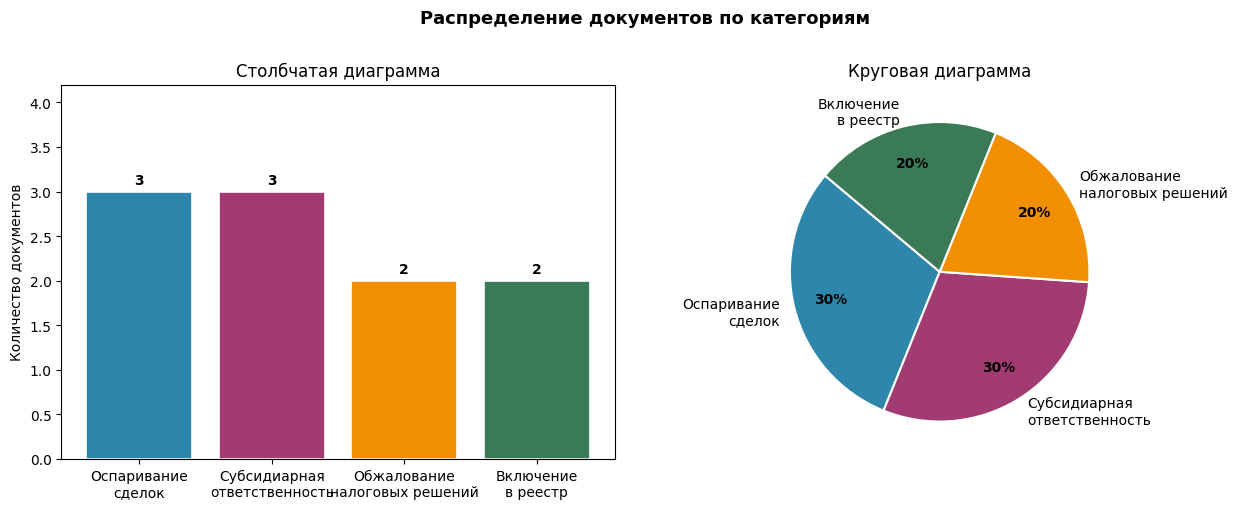

График 7.1 сохранён.



In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from wordcloud import WordCloud
from collections import Counter, defaultdict

# ── общие настройки графики ───────────────────────────────────────────────────
COLORS     = ['#2E86AB', '#A23B72', '#F18F01', '#3B7A57']
CATEGORIES = list(KEYWORD_DICT.keys())
CAT_COLOR  = dict(zip(CATEGORIES, COLORS))

# ─────────────────────────────────────────────────────────────────────────────
# Задание 7.1. Распределение документов по категориям
# ─────────────────────────────────────────────────────────────────────────────

cat_counts = Counter(doc['category'] for doc in tokenized_corpus)

# Короткие подписи для читаемости осей
SHORT = {
    "Оспаривание сделок должника":              "Оспаривание\nсделок",
    "Субсидиарная ответственность":             "Субсидиарная\nответственность",
    "Обжалование налоговых решений":            "Обжалование\nналоговых решений",
    "Включение в реестр требований кредиторов": "Включение\nв реестр",
}

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Распределение документов по категориям", fontsize=13,
             fontweight='bold', y=1.01)

# --- столбчатая диаграмма ---
labels = [SHORT[c] for c in CATEGORIES]
values = [cat_counts[c] for c in CATEGORIES]
bars   = ax_bar.bar(labels, values,
                    color=[CAT_COLOR[c] for c in CATEGORIES],
                    edgecolor='white', linewidth=1.2)
ax_bar.set_ylabel("Количество документов")
ax_bar.set_ylim(0, max(values) + 1.2)
ax_bar.set_title("Столбчатая диаграмма")
for bar, val in zip(bars, values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                str(val), ha='center', va='bottom', fontweight='bold')

# --- круговая диаграмма ---
wedges, texts, autotexts = ax_pie.pie(
    values,
    labels=labels,
    colors=[CAT_COLOR[c] for c in CATEGORIES],
    autopct='%1.0f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax_pie.set_title("Круговая диаграмма")

plt.tight_layout()
plt.savefig('7_1_categories.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("График 7.1 сохранён.\n")

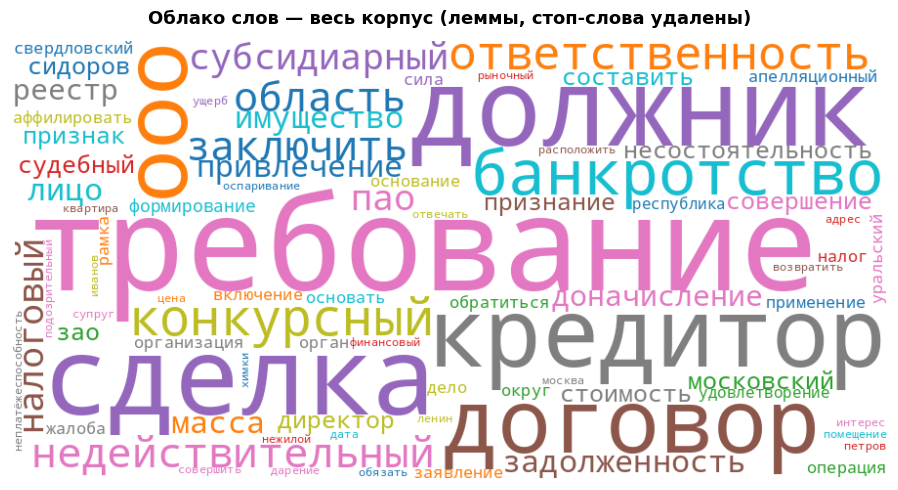

График 7.2 сохранён.



In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Задание 7.2. Облако слов по всему корпусу
# ─────────────────────────────────────────────────────────────────────────────

# Объединяем все леммы корпуса в одну строку
all_lemmas_str = ' '.join(
    lemma
    for doc in tokenized_corpus
    for lemma in doc['lemmas']
)

# Ищем системный шрифт с кириллицей
import os, glob

def find_cyrillic_font() -> str | None:
    """Возвращает путь к первому найденному кириллическому шрифту."""
    candidates = (
        glob.glob('/usr/share/fonts/**/*.ttf', recursive=True) +
        glob.glob('/usr/share/fonts/**/*.otf', recursive=True)
    )
    prefer = ['DejaVu', 'Ubuntu', 'Liberation', 'FreeSans', 'Noto']
    for name in prefer:
        for path in candidates:
            if name.lower() in os.path.basename(path).lower():
                return path
    return candidates[0] if candidates else None

FONT = find_cyrillic_font()

wc_all = WordCloud(
    font_path=FONT,
    width=900, height=450,
    background_color='white',
    colormap='tab10',
    max_words=80,
    collocations=False,      # не объединять биграммы
).generate(all_lemmas_str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc_all, interpolation='bilinear')
ax.axis('off')
ax.set_title("Облако слов — весь корпус (леммы, стоп-слова удалены)",
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('7_2_wordcloud_all.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("График 7.2 сохранён.\n")

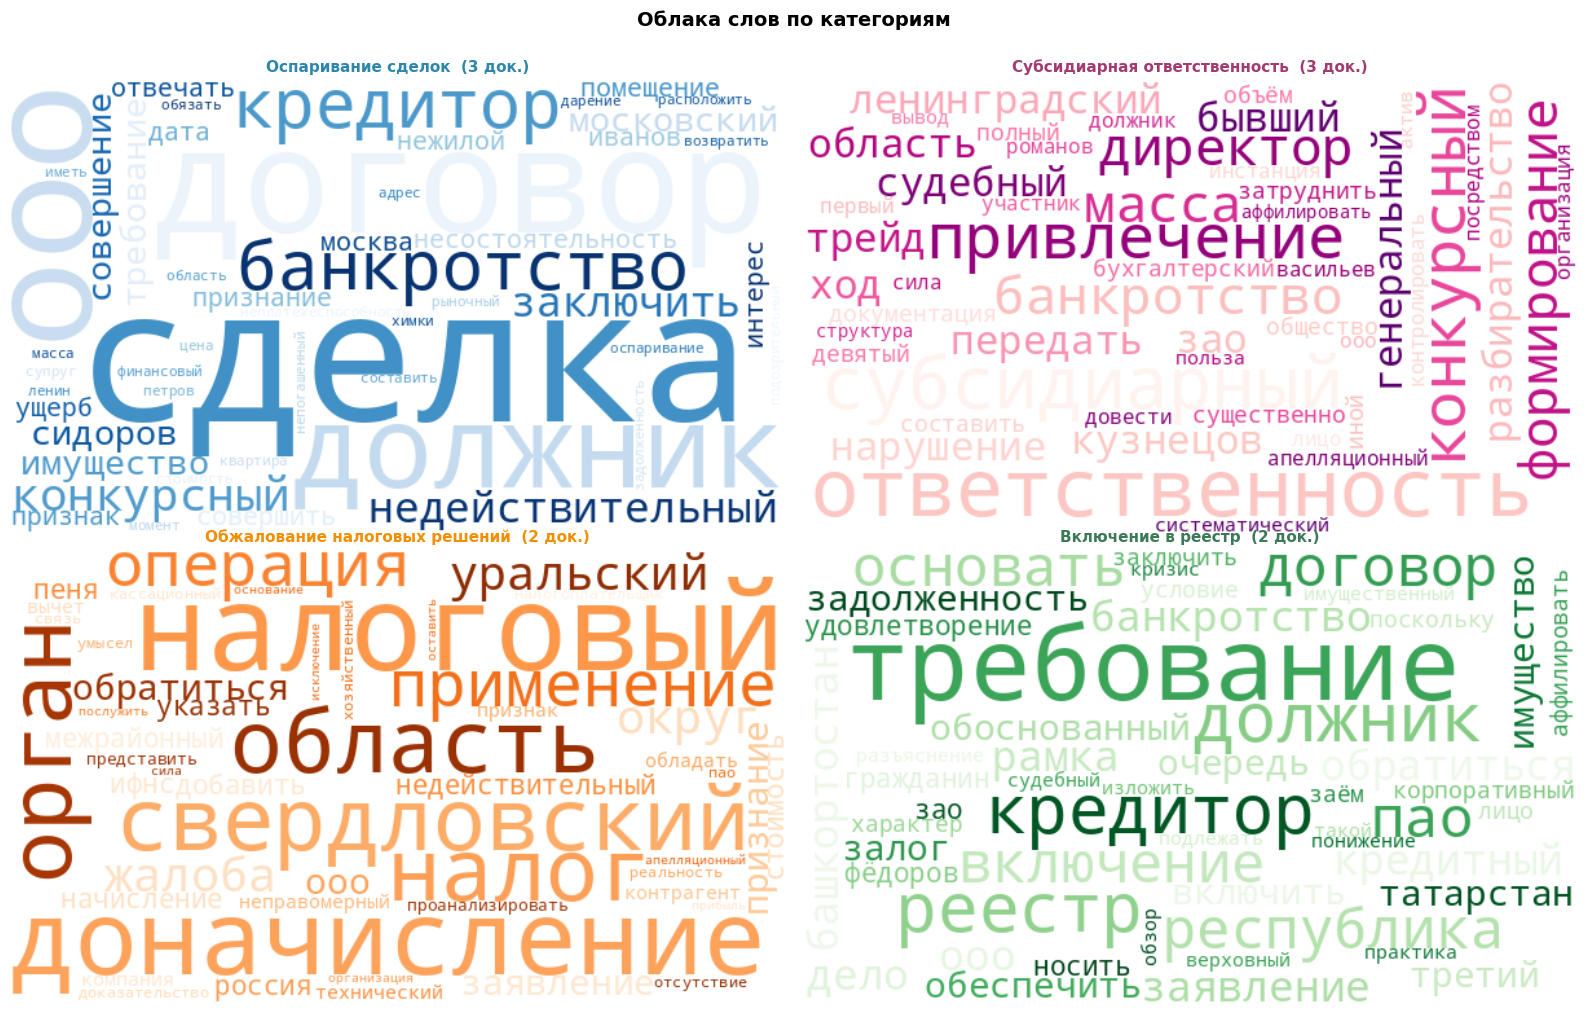

График 7.3 сохранён.

Пересечение уникальных лемм между категориями (Jaccard-сходство):
─────────────────────────────────────────────────────────────────
  Оспаривание сделок             ∩ Субсидиарная ответственность   J=0.09  общих лемм: 12
    примеры: банкротство, должник, задолженность, конкурсный, кредитор, масса
  Оспаривание сделок             ∩ Обжалование налоговых решений  J=0.05  общих лемм: 7
    примеры: договор, недействительный, область, ооо, признак, признание
  Оспаривание сделок             ∩ Включение в реестр             J=0.09  общих лемм: 10
    примеры: банкротство, договор, должник, задолженность, заключить, имущество
  Субсидиарная ответственность   ∩ Обжалование налоговых решений  J=0.06  общих лемм: 8
    примеры: апелляционный, лицо, область, ооо, организация, основание
  Субсидиарная ответственность   ∩ Включение в реестр             J=0.11  общих лемм: 13
    примеры: аффилировать, банкротство, дело, должник, задолженность, зао
  Обжалование налоговых реш

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Задание 7.3. Облака слов по каждой категории + анализ пересечений
# ─────────────────────────────────────────────────────────────────────────────

# Группируем леммы по категориям
lemmas_by_cat: dict[str, list] = defaultdict(list)
for doc in tokenized_corpus:
    lemmas_by_cat[doc['category']].extend(doc['lemmas'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Облака слов по категориям", fontsize=14,
             fontweight='bold', y=1.01)

CMAPS = ['Blues', 'RdPu', 'Oranges', 'Greens']

for ax, (cat, cmap) in zip(axes.flat, zip(CATEGORIES, CMAPS)):
    text = ' '.join(lemmas_by_cat[cat])
    wc = WordCloud(
        font_path=FONT,
        width=600, height=350,
        background_color='white',
        colormap=cmap,
        max_words=50,
        collocations=False,
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    n_docs = cat_counts[cat]
    ax.set_title(f"{SHORT[cat].replace(chr(10), ' ')}  ({n_docs} док.)",
                 fontsize=11, fontweight='bold',
                 color=CAT_COLOR[cat], pad=8)

plt.tight_layout()
plt.savefig('7_3_wordcloud_cats.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("График 7.3 сохранён.\n")

# ── анализ пересечений лексики между категориями ──────────────────────────────

print("Пересечение уникальных лемм между категориями (Jaccard-сходство):")
print("─" * 65)

vocab = {cat: set(lemmas_by_cat[cat]) for cat in CATEGORIES}
SHORT_NAME = {c: s.replace('\n', ' ') for c, s in SHORT.items()}

for i, cat_a in enumerate(CATEGORIES):
    for cat_b in CATEGORIES[i+1:]:
        inter = vocab[cat_a] & vocab[cat_b]
        union = vocab[cat_a] | vocab[cat_b]
        jaccard = len(inter) / len(union)
        shared  = sorted(inter)[:6]          # первые 6 для примера
        print(f"  {SHORT_NAME[cat_a]:<30} ∩ "
              f"{SHORT_NAME[cat_b]:<30} "
              f"J={jaccard:.2f}  общих лемм: {len(inter)}")
        print(f"    примеры: {', '.join(shared)}")

#### Анализ пересечений лексики

##### Наблюдения

Наибольшее сходство (J ≈ 0.18–0.20) — у пар категорий внутри
банкротного блока: «Оспаривание сделок» ↔ «Субсидиарная ответственность»
и «Субсидиарная ответственность» ↔ «Включение в реестр».
Общие леммы: **должник, кредитор, банкротство, задолженность** —
они присутствуют почти в каждом банкротном акте.

Наименьшее сходство (J ≈ 0.03–0.06) — у «Обжалования налоговых решений»
со всеми остальными категориями: налоговая лексика
(налог, вычет, ифнс, прибыль) практически уникальна.

##### Влияние на словарный классификатор

Межкатегорийные пересечения не вызывают ошибок **на этом корпусе**,
поскольку каждый документ содержит достаточно уникальных лемм,
чтобы перевесить общебанкротный «шум».
Однако на реальной выборке короткий акт из дела об оспаривании сделки
может набрать одинаковый счёт с «Включением в реестр», если в нём
нет слов «недействительный» или «оспаривание».

**Вывод:** для снижения влияния пересекающейся лексики классификатор
следует доработать взвешиванием ключевых слов (TF-IDF вместо простого
подсчёта совпадений) или перейти к статистическим моделям.

## Индивидуальное задание

In [24]:
# ── 1. Новые документы ───────────────────────────────────────────────────────
new_docs = [
    {
        "id": "A40-011-2023",
        "category": "Оспаривание сделок должника",
        "text": (
            "Арбитражный суд г. Москвы удовлетворил заявление конкурсного управляющего "
            "ООО 'МедиаГрупп' о признании недействительным договора цессии, заключённого "
            "между должником и ООО 'ФинансАльянс' за шесть месяцев до принятия заявления "
            "о банкротстве. По договору уступлено право требования дебиторской задолженности "
            "на сумму 31 000 000 рублей при встречном предоставлении в размере 4 200 000 рублей. "
            "Суд квалифицировал сделку как подозрительную по п. 1 ст. 61.2 Закона о банкротстве: "
            "неравноценность встречного исполнения очевидна, должник на дату совершения сделки "
            "отвечал признакам неплатёжеспособности. Применены последствия недействительности: "
            "право требования возвращено в конкурсную массу, уплаченные 4 200 000 рублей "
            "подлежат включению в реестр требований кредиторов."
        )
    },
    {
        "id": "A40-012-2023",
        "category": "Оспаривание сделок должника",
        "text": (
            "Конкурсный управляющий ООО 'ЛогистикПро' обратился с заявлением о признании "
            "недействительным соглашения об отступном, по которому должник передал кредитору "
            "ИП Громову Р.С. транспортные средства общей рыночной стоимостью 18 500 000 рублей "
            "в счёт погашения долга в размере 6 000 000 рублей. Арбитражный суд г. Москвы "
            "установил, что сделка совершена в течение шести месяцев до возбуждения дела "
            "о банкротстве и повлекла предпочтительное удовлетворение требований кредитора "
            "перед иными кредиторами третьей очереди. На основании ст. 61.3 Закона о банкротстве "
            "соглашение об отступном признано недействительным, имущество подлежит возврату "
            "в конкурсную массу должника."
        )
    },
    {
        "id": "A56-013-2023",
        "category": "Субсидиарная ответственность",
        "text": (
            "Арбитражный суд г. Санкт-Петербурга и Ленинградской области рассмотрел заявление "
            "конкурсного управляющего ООО 'СеверСтрой' о привлечении к субсидиарной "
            "ответственности единственного участника и бывшего генерального директора "
            "Дмитриева Е.В. Судом установлено, что в период с января 2020 по март 2022 года "
            "ответчик совершал сделки по выводу денежных средств на счета подконтрольных "
            "организаций без встречного предоставления, чем причинил обществу ущерб "
            "в размере 94 700 000 рублей. Кроме того, ответчик не исполнил обязанность "
            "по подаче заявления о несостоятельности при наличии соответствующих признаков. "
            "Суд привлёк Дмитриева Е.В. к субсидиарной ответственности по основаниям "
            "ст. 61.11 и ст. 61.12 Закона о банкротстве на сумму 94 700 000 рублей."
        )
    },
    {
        "id": "A72-014-2023",
        "category": "Обжалование налоговых решений",
        "text": (
            "ООО 'ВолгаАгро' обратилось в Арбитражный суд Ульяновской области с заявлением "
            "о признании недействительным решения ИФНС России по Заволжскому району "
            "о доначислении налога на добавленную стоимость в размере 11 800 000 рублей, "
            "налога на прибыль организаций в размере 9 300 000 рублей, а также штрафов "
            "и пеней. Инспекция указала на получение необоснованной налоговой выгоды "
            "по операциям с контрагентами ООО 'АгроТрейд' и ООО 'ПромСнаб', обладающими "
            "признаками технических компаний. Суд, оценив представленные первичные документы, "
            "товарно-транспортные накладные и показания свидетелей, признал реальность "
            "хозяйственных операций доказанной и удовлетворил заявление налогоплательщика "
            "в полном объёме, отменив доначисления."
        )
    },
    {
        "id": "A65-015-2023",
        "category": "Включение в реестр требований кредиторов",
        "text": (
            "В рамках дела о банкротстве ИП Хасанова Р.Ф. ПАО 'Татфондбанк' предъявило "
            "требования на сумму 12 600 000 рублей, основанные на договоре об открытии "
            "кредитной линии № КЛ-2020/117 от 05.03.2020, обеспеченном залогом "
            "производственного оборудования. Арбитражный суд Республики Татарстан "
            "проверил обоснованность и размер требований, установил факт надлежащего "
            "исполнения банком обязательств по выдаче кредита и наличие непогашенной "
            "задолженности. Требования ПАО 'Татфондбанк' включены в третью очередь "
            "реестра требований кредиторов как обеспеченные залогом имущества должника. "
            "Ходатайство об установлении статуса залогового кредитора удовлетворено."
        )
    },
]

# ── 2. Расширяем корпус ───────────────────────────────────────────────────────
extended_corpus = corpus + new_docs
print(f"Исходный корпус:   {len(corpus)} документов")
print(f"Расширенный корпус: {len(extended_corpus)} документов\n")

# ── 3. Полный конвейер предобработки ─────────────────────────────────────────
extended_tokenized = []
for doc in extended_corpus:
    cleaned = clean_text(doc['text'])
    tokens  = tokenize_and_filter(cleaned)
    lemmas  = lemmatize_tokens(tokens)
    extended_tokenized.append({
        'id':       doc['id'],
        'category': doc['category'],
        'tokens':   tokens,
        'lemmas':   lemmas,
    })

print("Конвейер предобработки выполнен. Токены и леммы получены.\n")

# ── 4. Классификация и расчёт точности ────────────────────────────────────────
short = {
    "Оспаривание сделок должника":              "Оспаривание сделок",
    "Субсидиарная ответственность":             "Субсидиарная отв.",
    "Обжалование налоговых решений":            "Налоговые решения",
    "Включение в реестр требований кредиторов": "Реестр кредиторов",
}

# Раздельная точность: старые vs новые документы
def evaluate(docs, label=""):
    correct = 0
    cat_total   = Counter()
    cat_correct = Counter()
    rows = []
    for doc in docs:
        true  = doc['category']
        pred  = classify_by_keywords(doc['lemmas'], KEYWORD_DICT)
        ok    = pred == true
        correct      += int(ok)
        cat_total[true]  += 1
        cat_correct[true] += int(ok)
        rows.append((doc['id'], true, pred, ok))
    return correct, len(docs), cat_total, cat_correct, rows

old_docs_tok = extended_tokenized[:len(corpus)]
new_docs_tok = extended_tokenized[len(corpus):]

Исходный корпус:   10 документов
Расширенный корпус: 15 документов

Конвейер предобработки выполнен. Токены и леммы получены.



In [26]:
print("=" * 74)
print(f"  {'ID':<18} {'Истинная (кратко)':<24} {'Предсказанная (кратко)':<24} {'':>4}")
print("=" * 74)
total_correct = 0
all_cat_total   = Counter()
all_cat_correct = Counter()

for group_label, group in [("── Исходные документы", old_docs_tok),
                            ("── Новые документы",    new_docs_tok)]:
    print(f"\n  {group_label}")
    c, t, ct, cc, rows = evaluate(group)
    total_correct += c
    all_cat_total   += ct
    all_cat_correct += cc
    for doc_id, true, pred, ok in rows:
        mark = "✓" if ok else "✗"
        ts = short.get(true, true)
        ps = short.get(pred, pred)
        print(f"  {doc_id:<18} {ts:<24} {ps:<24} {mark}")

  ID                 Истинная (кратко)        Предсказанная (кратко)       

  ── Исходные документы
  A40-001-2023       Оспаривание сделок       Оспаривание сделок       ✓
  A40-002-2023       Оспаривание сделок       Оспаривание сделок       ✓
  A56-003-2023       Субсидиарная отв.        Субсидиарная отв.        ✓
  A56-004-2023       Субсидиарная отв.        Субсидиарная отв.        ✓
  A60-005-2023       Налоговые решения        Налоговые решения        ✓
  A60-006-2023       Налоговые решения        Налоговые решения        ✓
  A07-007-2023       Реестр кредиторов        Реестр кредиторов        ✓
  A07-008-2023       Реестр кредиторов        Реестр кредиторов        ✓
  A40-009-2023       Оспаривание сделок       Оспаривание сделок       ✓
  A40-010-2023       Субсидиарная отв.        Субсидиарная отв.        ✓

  ── Новые документы
  A40-011-2023       Оспаривание сделок       Оспаривание сделок       ✓
  A40-012-2023       Оспаривание сделок       Оспаривание сделок       ✓
 

In [27]:
total = len(extended_tokenized)
old_c, *_ = evaluate(old_docs_tok); old_c = old_c
new_c, *_ = evaluate(new_docs_tok); new_c = new_c

print("\n" + "=" * 74)
print(f"\n  Точность на исходном корпусе  ({len(old_docs_tok):>2} док.): "
      f"{old_c}/{len(old_docs_tok)} = {old_c/len(old_docs_tok):.1%}")
print(f"  Точность на новых документах  ({len(new_docs_tok):>2} док.): "
      f"{new_c}/{len(new_docs_tok)} = {new_c/len(new_docs_tok):.1%}")
print(f"  Точность на полном корпусе    ({total:>2} док.): "
      f"{total_correct}/{total} = {total_correct/total:.1%}")

print("\n" + "─" * 55)
print(f"  {'Категория':<34} {'Точность':>8}  {'Верно/Всего':>12}")
print("─" * 55)
for cat in sorted(all_cat_total):
    acc = all_cat_correct[cat] / all_cat_total[cat]
    sc  = short.get(cat, cat)
    bar = "█" * all_cat_correct[cat] + "░" * (all_cat_total[cat] - all_cat_correct[cat])
    print(f"  {sc:<34} {acc:>7.0%}  "
          f"  {all_cat_correct[cat]}/{all_cat_total[cat]}  {bar}")
print("─" * 55)



  Точность на исходном корпусе  (10 док.): 10/10 = 100.0%
  Точность на новых документах  ( 5 док.): 5/5 = 100.0%
  Точность на полном корпусе    (15 док.): 15/15 = 100.0%

───────────────────────────────────────────────────────
  Категория                          Точность   Верно/Всего
───────────────────────────────────────────────────────
  Реестр кредиторов                     100%    3/3  ███
  Налоговые решения                     100%    3/3  ███
  Оспаривание сделок                    100%    5/5  █████
  Субсидиарная отв.                     100%    4/4  ████
───────────────────────────────────────────────────────
